In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Global_Happiness.csv')
df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [2]:
print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    str    
 1   Region                         158 non-null    str    
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), str(2)
memory u

In [3]:
df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


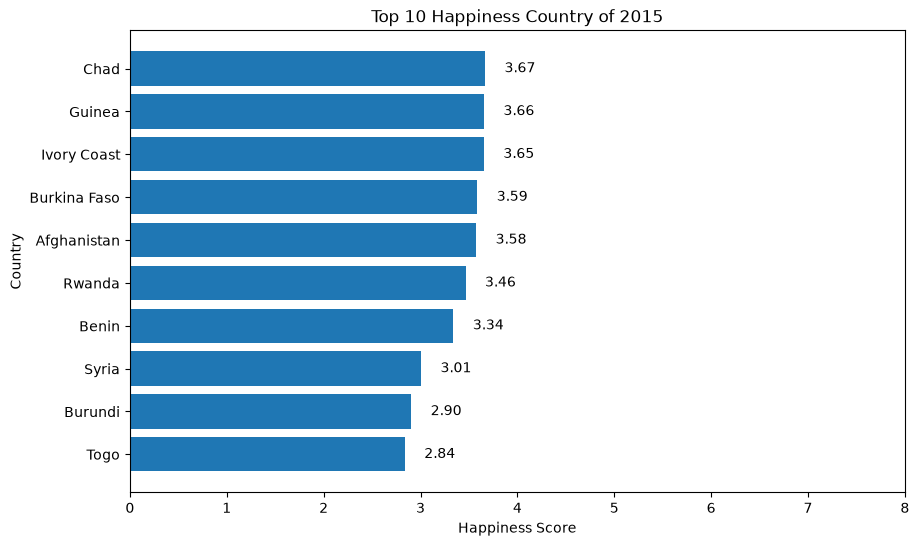

In [4]:
top10 = df.sort_values(by='Happiness Score', ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['Country'], top10['Happiness Score'])
plt.title('Top 10 Happiness Country of 2015')
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.xlim(0, 8)

for index, value in enumerate(top10['Happiness Score']):
    plt.text(value + 0.2, index, f'{value:.2f}', color='black', va='center')

plt.show()

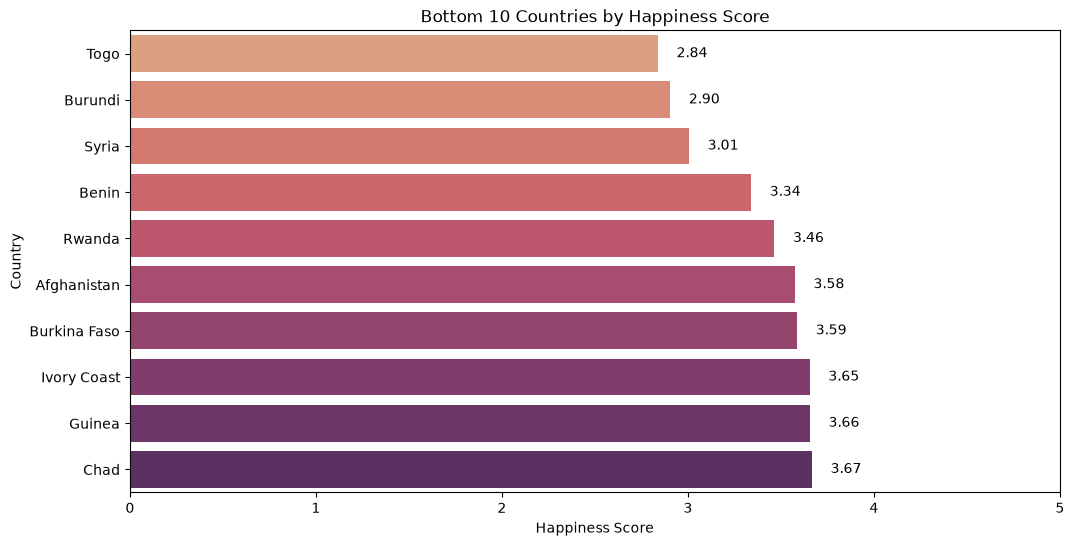

In [5]:
bottom10 = df.nsmallest(10, 'Happiness Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=bottom10, x='Happiness Score', y='Country', hue='Country', palette='flare', legend=False)
plt.title('Bottom 10 Countries by Happiness Score')
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.xlim(0, 5)

for index, value in enumerate(bottom10['Happiness Score']):
    plt.text(value + 0.1, index, f'{value:.2f}', color='black', va='center')

plt.show()

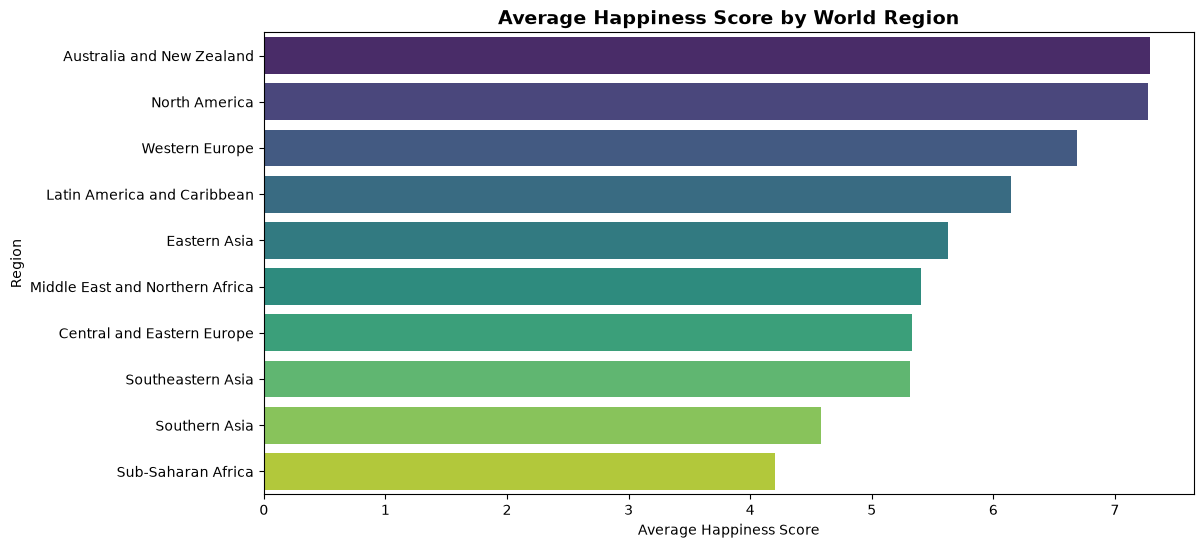

In [6]:
region_avg = df.groupby('Region')['Happiness Score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(data=region_avg, x='Happiness Score', y='Region', hue='Region', palette='viridis', legend=False)

plt.title('Average Happiness Score by World Region', fontsize=14, fontweight='bold')
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')

plt.show()

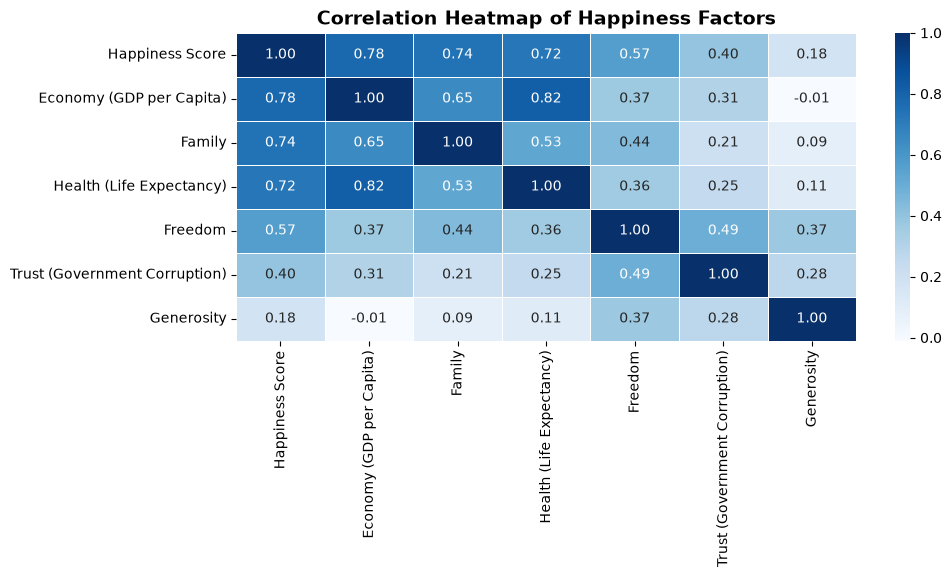

In [7]:
factors = ['Happiness Score', 'Economy (GDP per Capita)', 'Family', 
           'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity']

corr_matrix = df[factors].corr()

plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Happiness Factors', fontsize=14, fontweight='bold')
plt.show()

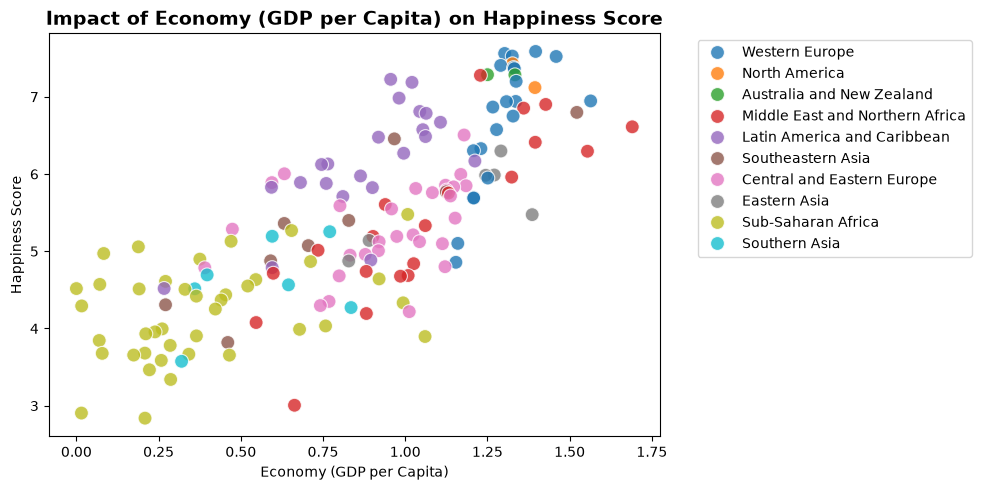

In [8]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score', hue='Region', s=100, alpha=0.8)
plt.title('Impact of Economy (GDP per Capita) on Happiness Score', fontsize=14, fontweight='bold')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
top_country = top10.iloc[0]['Country']
top_score = top10.iloc[0]['Happiness Score']

lowest_country = bottom10.iloc[0]['Country']
lowest_score = bottom10.iloc[0]['Happiness Score']

top_region = region_avg.iloc[0]['Region']

print("================ GLOBAL HAPPINESS SUMMARY REPORT ================")
print(f"1. Happiest Country: {top_country} (Score: {top_score})")
print(f"2. Least Happy Country: {lowest_country} (Score: {lowest_score})")
print(f"3. Happiest Region: {top_region}")
print("4. Key Driving Factors: Economy (GDP), Family Support, and Health (Life Expectancy).")
print("================================================================")

================ GLOBAL HAPPINESS SUMMARY REPORT ================
1. Happiest Country: Togo (Score: 2.839)
2. Least Happy Country: Togo (Score: 2.839)
3. Happiest Region: Australia and New Zealand
4. Key Driving Factors: Economy (GDP), Family Support, and Health (Life Expectancy).


In [ ]:
# 📊 Good Key Insights – Global Happiness Report Analysis

## 🌍 Overall Findings
- The dataset shows that countries with higher happiness scores generally have better economic and social conditions.
- GDP per capita has a positive impact on the happiness level of a country.
- Social support is one of the strongest contributors to overall happiness.
- Healthy life expectancy is positively associated with happiness scores.
- Freedom to make life choices contributes significantly to citizens' well-being.
- Lower corruption perception is generally observed in countries with higher happiness scores.
- Generosity shows a weaker relationship with happiness compared to GDP and social support.

## 📈 Visualization Insights
- Bar charts clearly identify the happiest and least happy countries.
- Scatter plots reveal a positive relationship between GDP and Happiness Score.
- Line charts help compare happiness scores across different countries.
- Heatmaps highlight correlations between numerical variables.
- Pie charts effectively represent the distribution of countries across different regions.

## 📌 Statistical Insights
- The mean happiness score provides an estimate of the overall global happiness level.
- Standard deviation indicates noticeable variation in happiness among countries.
- Maximum and minimum values identify the happiest and least happy countries in the dataset.
- Correlation analysis shows that GDP, social support, and life expectancy are strongly related to happiness.

## 💡 Conclusion
The analysis indicates that happiness is influenced by multiple socioeconomic factors rather than a single variable. 
Countries with stronger economies, better healthcare, higher social support, and greater personal freedom generally achieve higher happiness scores. 
Data visualization and statistical analysis make these relationships easier to understand and support meaningful decision-making.